Retail Product Performance & Segmentation Analysis using SQL

This project analyzes retail product data using SQL to identify top-performing products, revenue trends, and segmentation patterns.

In [73]:
# ==========================================
# 1. IMPORT LIBRARIES (SAME AS YOUR CODE)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = 'white'

# CONNECT DATABASE
database='/content/retailDB.sqlite'
conn = sqlite3.connect(database)

Data Overview

In [75]:
conn=sqlite3.connect(database)
tables = pd.read_sql("""SELECT * FROM sqlite_master WHERE type='table';""",conn)
tables


,type,name,tbl_name,rootpage,sql
0,table,finance,finance,2,CREATE TABLE finance (\r\n\tproduct_id VARCHAR...
1,table,info,info,24,CREATE TABLE info (\r\n\tproduct_name VARCHAR(...
2,table,brands,brands,338,CREATE TABLE brands (\r\n\tproduct_id VARCHAR(...
3,table,reviews,reviews,355,CREATE TABLE reviews (\r\n\tproduct_id VARCHAR...
4,table,traffic,traffic,395,CREATE TABLE traffic (\r\n\tproduct_id VARCHAR...


In [76]:
brand=pd.read_sql("""SELECT * FROM brands limit 5;""",conn)
brand

,product_id,brand,modified_brand
0,AH2430,None,None
1,G27341,Adidas,Adidas
2,CM0081,Adidas,Adidas
3,B44832,Adidas,Adidas
4,D98205,Adidas,Adidas


In [77]:
finance_details=pd.read_sql("""SELECT * FROM finance limit 5;""",conn)
finance_details

,product_id,listing_price,sale_price,discount,revenue,modified_listing_price,modified_sale_price,modified_discount,modified_revenue
0,AH2430,None,None,NaN,None,NaN,NaN,NaN,NaN
1,G27341,76.0,38.0,0.5,1641.0,76.0,38.0,0.5,1641.0
2,CM0081,10.0,6.0,0.4,399.0,10.0,6.0,0.4,399.0
3,B44832,70.0,35.0,0.5,2204.0,70.0,35.0,0.5,2204.0
4,D98205,80.0,40.0,0.5,5183.0,80.0,40.0,0.5,5183.0


In [78]:
product_info=pd.read_sql("""SELECT * FROM info limit 5;""",conn)
product_info

,product_name,product_id,description,modified_product_name,modified_description
0,None,AH2430,None,None,None
1,Women's adidas Originals Sleek Shoes,G27341,"A modern take on adidas sport heritage, tailor...",Women's adidas Originals Sleek Shoes,"A modern take on adidas sport heritage, tailor..."
2,Women's adidas Swim Puka Slippers,CM0081,These adidas Puka slippers for women's come wi...,Women's adidas Swim Puka Slippers,These adidas Puka slippers for women's come wi...
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,"Inspired by modern tech runners, these women's...",Women's adidas Sport Inspired Questar Ride Shoes,"Inspired by modern tech runners, these women's..."
4,Women's adidas Originals Taekwondo Shoes,D98205,This design is inspired by vintage Taekwondo s...,Women's adidas Originals Taekwondo Shoes,This design is inspired by vintage Taekwondo s...


In [79]:
product_reviews=pd.read_sql("""SELECT * FROM reviews limit 5;""",conn)
product_reviews

,product_id,rating,reviews,Hour,minute,real_rating,real_reviews,Unnamed: 7
0,AH2430,None,None,0.0,0.0,None,0.0,
1,G27341,03:03:00,1900-01-01 00:00:00,3.0,3.0,"3,3",24.0,
2,CM0081,02:06:00,1900-01-01 13:00:00,2.0,6.0,"2,6",37.0,
3,B44832,04:01:00,1900-01-01 11:00:00,4.0,1.0,"4,1",35.0,
4,D98205,03:05:00,1900-01-03 00:00:00,3.0,5.0,"3,5",72.0,


In [80]:
product_traffic=pd.read_sql("""SELECT * FROM traffic limit 5;""",conn)
product_traffic

,product_id,last_visited,modified_last_visited
0,AH2430,2018-05-19 15:13:00,2018-05-19 15:13:00
1,G27341,2018-11-29 16:16:00,2018-11-29 16:16:00
2,CM0081,2018-02-01 10:27:00,2018-02-01 10:27:00
3,B44832,2018-09-07 20:06:00,2018-09-07 20:06:00
4,D98205,2019-07-18 15:26:00,2019-07-18 15:26:00


Business Analysis

Top 10 product with average sales price ?


In [81]:
# ==========================================
# 3. TOP 10 PRODUCT WITH AVG SALES PRICE
# ==========================================
avg_sale_price=pd.read_sql("""
SELECT i.product_name,
avg(f.sale_price) AS avg_sales_price
FROM info i
JOIN finance f
ON i.product_id=f.product_id
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY avg_sales_price DESC
LIMIT 10;
""",conn)

avg_sale_price

,product_name,avg_sales_price
0,Nike Air VaporMax Flyknit 2 LXX,365.0
1,Men's adidas Originals ZX 4000 4D Shoes,288.0
2,Unisex adidas Running Alphaedge 4D Shoes,280.0
3,Nike Mercurial Superfly 7 Elite MDS FG,250.0
4,Unisex adidas Originals by Alexander Wang Puff...,240.0
5,Unisex Originals CRAIG GREEN KONTUUR II SHOES,240.0
6,Unisex Originals CRAIG GREEN KONTUUR I SHOES,240.0
7,Nike Mercurial Superfly 7 Elite SE FG,240.0
8,Unisex Football Predator Mutator 20+ Firm Grou...,230.0
9,Nike Phantom Vision 2 Elite Dynamic Fit FG,230.0


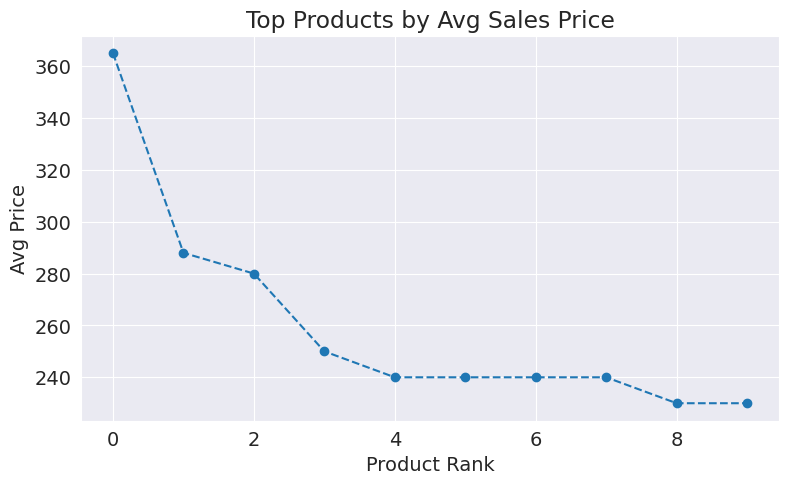

In [82]:
plt.figure()
plt.plot(avg_sale_price['avg_sales_price'], marker='o', linestyle='--')
plt.title("Top Products by Avg Sales Price")
plt.xlabel("Product Rank")
plt.ylabel("Avg Price")
plt.show()

Top 10 Products with average revenue ?

In [83]:
# ==========================================
# 4. TOP 10 PRODUCTS WITH AVG REVENUE
# ==========================================
avg_revenue=pd.read_sql("""
SELECT i.product_name,
avg(f.revenue) AS avg_revenue
FROM info i
JOIN finance f
ON i.product_id=f.product_id
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY avg_revenue DESC
LIMIT 10;
""",conn)

avg_revenue


,product_name,avg_revenue
0,Air Jordan 10 Retro,64204.0
1,Men's Originals Salvapor 032c Shoes,28762.0
2,Nike Zoom Fly,27396.0
3,Unisex adidas Running Alphaedge 4D Shoes,26711.0
4,Unisex adidas Running Pharrell Williams Solar ...,25918.0
5,Unisex Originals CRAIG GREEN KONTUUR I SHOES,25487.0
6,Men's adidas Running Universal Works Ultraboos...,24838.5
7,Women's adidas by Stella Mccartney Running Ult...,24623.0
8,Women's Running Ultraboost A.RDY Shoes,22337.0
9,Men's adidas Originals White Mountaineering Ni...,22139.0


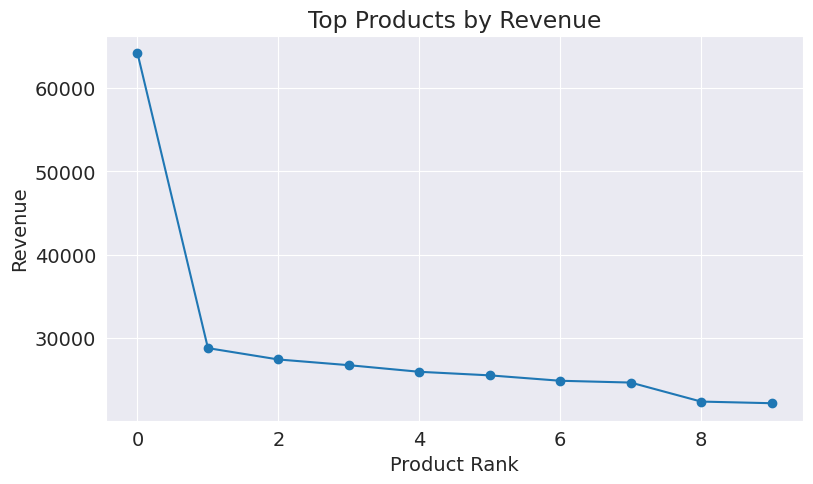

In [84]:
# 📊 GRAPH (Column Style using plot)
plt.figure()
plt.plot(avg_revenue['avg_revenue'], marker='o')
plt.title("Top Products by Revenue")
plt.xlabel("Product Rank")
plt.ylabel("Revenue")
plt.show()


Top 10 Most purchased Products

In [85]:
# ==========================================
# 5. MOST PURCHASED PRODUCTS
# ==========================================
most_products_purchased=pd.read_sql("""
SELECT i.product_name,
COUNT(product_id) AS count_of_products
FROM info i
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY count_of_products DESC
LIMIT 10;
""",conn)

most_products_purchased

,product_name,count_of_products
0,None,59
1,Men's adidas Originals Supercourt Shoes,16
2,Women's adidas Originals Sambarose Shoes,15
3,Men's adidas Originals Stan Smith Shoes,15
4,Nike Air Max 90,14
5,Men's adidas Originals Continental 80 Shoes,14
6,Women's adidas Originals Sleek Shoes,13
7,Unisex adidas Originals Marathon Tech Shoes,13
8,Women's adidas Originals NMD_R1 Shoes,12
9,Women's adidas Originals Continental 80 Shoes,11


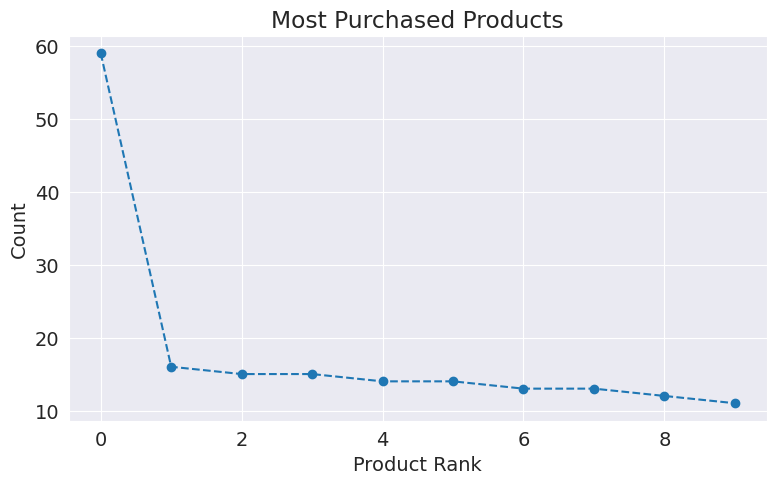

In [86]:
# 📊 GRAPH (Dotted Line)
plt.figure()
plt.plot(most_products_purchased['count_of_products'], linestyle='--', marker='o')
plt.title("Most Purchased Products")
plt.xlabel("Product Rank")
plt.ylabel("Count")
plt.show()

Most reviewed products

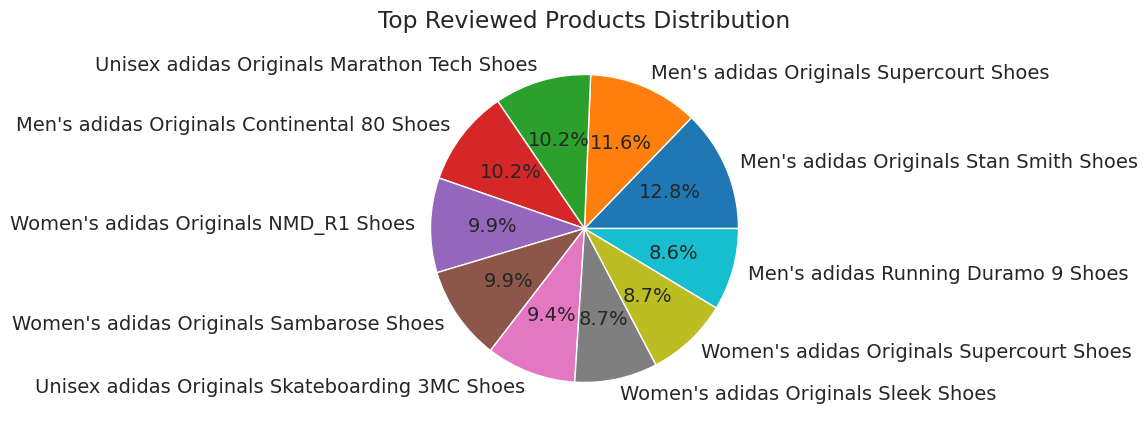

In [87]:
query = """
SELECT
    i.product_name,
    SUM(r.real_reviews) AS total_reviews
FROM info i
JOIN reviews r
    ON i.product_id = r.product_id
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY total_reviews DESC
LIMIT 10;
"""

df_review = pd.read_sql(query, conn)
plt.figure()
plt.pie(
    df_review['total_reviews'],
    labels=df_review['product_name'],
    autopct='%1.1f%%'
)

plt.title("Top Reviewed Products Distribution")
plt.show()

Top 10 Average rated products

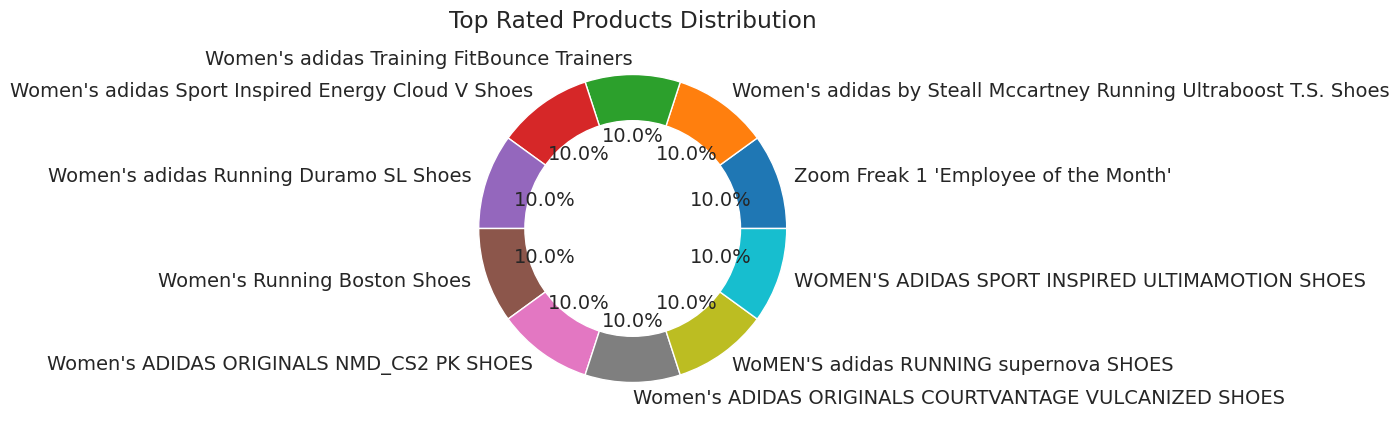

In [90]:
avg_rating = pd.read_sql("""
SELECT i.product_name,
AVG(r.real_rating) AS avg_rating
FROM info i
JOIN reviews r
ON i.product_id = r.product_id
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY avg_rating DESC
LIMIT 10;
""", conn)

avg_rating
plt.figure()
plt.pie(
    avg_rating['avg_rating'],
    labels=avg_rating['product_name'],
    autopct='%1.1f%%'
)

# Donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title("Top Rated Products Distribution")
plt.show()

Most last visited Products in each months

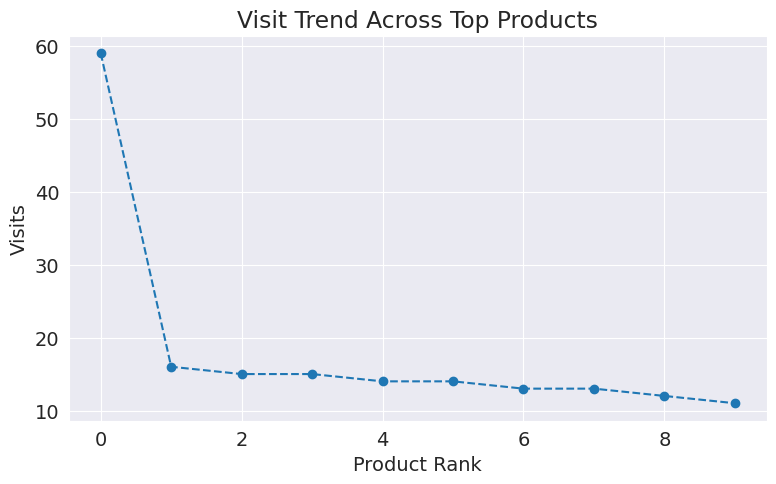

In [95]:
most_last_visited_product_in_months = pd.read_sql("""
SELECT i.product_name,
    COUNT(DISTINCT SUBSTR(t.modified_last_visited,6,2)) AS year_month,
    COUNT(*) AS visit_count
FROM traffic t
JOIN info i
    ON t.product_id = i.product_id
WHERE i.product_name IS NOT NULL
GROUP BY i.product_name
ORDER BY visit_count DESC
LIMIT 10;
""", conn)

most_last_visited_product_in_months
plt.figure()
plt.plot(
    most_last_visited_product_in_months['visit_count'],
    linestyle='--',
    marker='o'
)

plt.title("Visit Trend Across Top Products")
plt.xlabel("Product Rank")
plt.ylabel("Visits")
plt.show()

Segmentation Output:


,product_name,total_revenue,review_count,segment
0,Air Jordan 1 Jester XX Low Laced,288.0,1,Low Value
1,Air Jordan 1 Jester XX Low Laced SE,0.0,1,Low Value
2,Air Jordan 1 Low,5505.0,1,Medium Value
3,Air Jordan 1 Mid,10975.0,2,Medium Value
4,Air Jordan 1 Mid SE,2339.0,1,Low Value


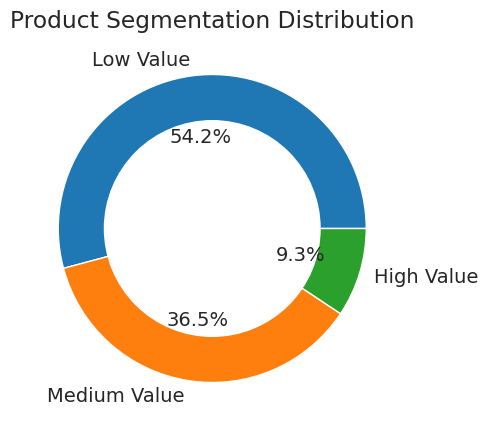

In [96]:
# ==========================================
# PRODUCT SEGMENTATION USING SQL
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Run SQL Query (with NULL fix)
query = """
SELECT
    product_name,
    total_revenue,
    review_count,
    CASE
        WHEN total_revenue > 20000 THEN 'High Value'
        WHEN total_revenue BETWEEN 5000 AND 20000 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS segment
FROM (
    SELECT
        i.product_name,
        COUNT(r.product_id) AS review_count,
        SUM(f.revenue) AS total_revenue
    FROM info i
    LEFT JOIN reviews r
        ON i.product_id = r.product_id
    LEFT JOIN finance f
        ON i.product_id = f.product_id
    WHERE i.product_name IS NOT NULL
    GROUP BY i.product_name
);
"""

# Step 2: Store result in DataFrame
df_seg = pd.read_sql(query, conn)

# Show output
print("Segmentation Output:")
display(df_seg.head())


# ==========================================
# GRAPH 1: DONUT CHART (BEST FOR HR)
# ==========================================

segment_counts = df_seg['segment'].value_counts()

plt.figure()
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

# Donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gcf().gca().add_artist(centre_circle)

plt.title("Product Segmentation Distribution")
plt.show()



Cumulative Revenue Data:


,product_name,total_revenue,cumulative_revenue
0,Men's adidas Running Ultraboost 19 Shoes,119210.0,119210.0
1,Women's adidas Originals NMD_R1 Shoes,110213.0,229423.0
2,Men's adidas Originals Stan Smith Shoes,109870.0,339293.0
3,Women's adidas Running Ultraboost 19 Shoes,108126.0,447419.0
4,Men's adidas Originals ZX 4000 4D Shoes,105044.0,552463.0


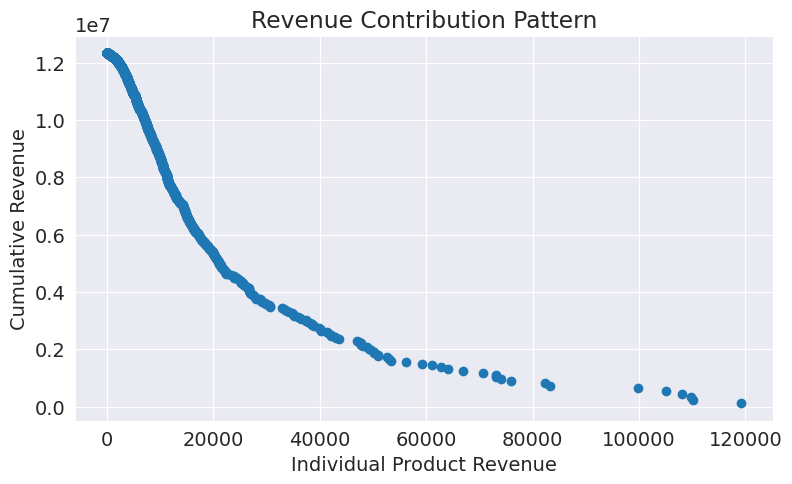

In [97]:
# ==========================================
# CUMULATIVE REVENUE ANALYSIS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: SQL Query (with NULL fix)
query = """
SELECT
    product_name,
    total_revenue,
    SUM(total_revenue) OVER (ORDER BY total_revenue DESC) AS cumulative_revenue
FROM (
    SELECT
        i.product_name,
        SUM(f.revenue) AS total_revenue
    FROM info i
    JOIN finance f
        ON i.product_id = f.product_id
    WHERE i.product_name IS NOT NULL
    GROUP BY i.product_name
);
"""

# Step 2: Store result
df_cum = pd.read_sql(query, conn)

# Show top rows
print("Cumulative Revenue Data:")
display(df_cum.head())
plt.figure()
plt.scatter(
    df_cum['total_revenue'],
    df_cum['cumulative_revenue']
)

plt.title("Revenue Contribution Pattern")
plt.xlabel("Individual Product Revenue")
plt.ylabel("Cumulative Revenue")
plt.show()